# LLM Prediction Split / Metrics 

## Imports and Config

🔍 Looking in: C:\Users\nehan\Documents\GT\CS 4641\ML_vs_LLM_COVID_GenderBias\Metric Output Files\CML — Found 38 files
✅ Loaded: Catboost | AllFemalePregnant | Covid-19Presence
✅ Loaded: Catboost | AllFemalePregnant | Death
✅ Loaded: Catboost | AllFemalePregnant | Pneumonia
✅ Loaded: Catboost | AllFemale | Covid-19Presence
✅ Loaded: Catboost | AllFemale | Covid-19Severity
✅ Loaded: Catboost | AllFemale | Death
✅ Loaded: Catboost | AllFemale | Pneumonia
✅ Loaded: Catboost | AllMale | Covid-19Presence
✅ Loaded: Catboost | AllMale | Covid-19Severity
✅ Loaded: Catboost | AllMale | Death
✅ Loaded: Catboost | AllMale | Pneumonia
✅ Loaded: Catboost | GenderBalanced | Covid-19Presence
✅ Loaded: Catboost | GenderBalanced | Covid-19Severity
✅ Loaded: Catboost | GenderBalanced | Death
✅ Loaded: Catboost | GenderBalanced | Pneumonia
✅ Loaded: Catboost | GenderUnbalanced | Covid-19Presence
✅ Loaded: Catboost | GenderUnbalanced | Covid-19Severity
✅ Loaded: Catboost | GenderUnbalanced | Death
✅ Loaded

C:\Users\nehan\AppData\Local\Temp\ipykernel_25536\956012294.py:83: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_metric, x="target", y=metric, hue="model", ci=None)


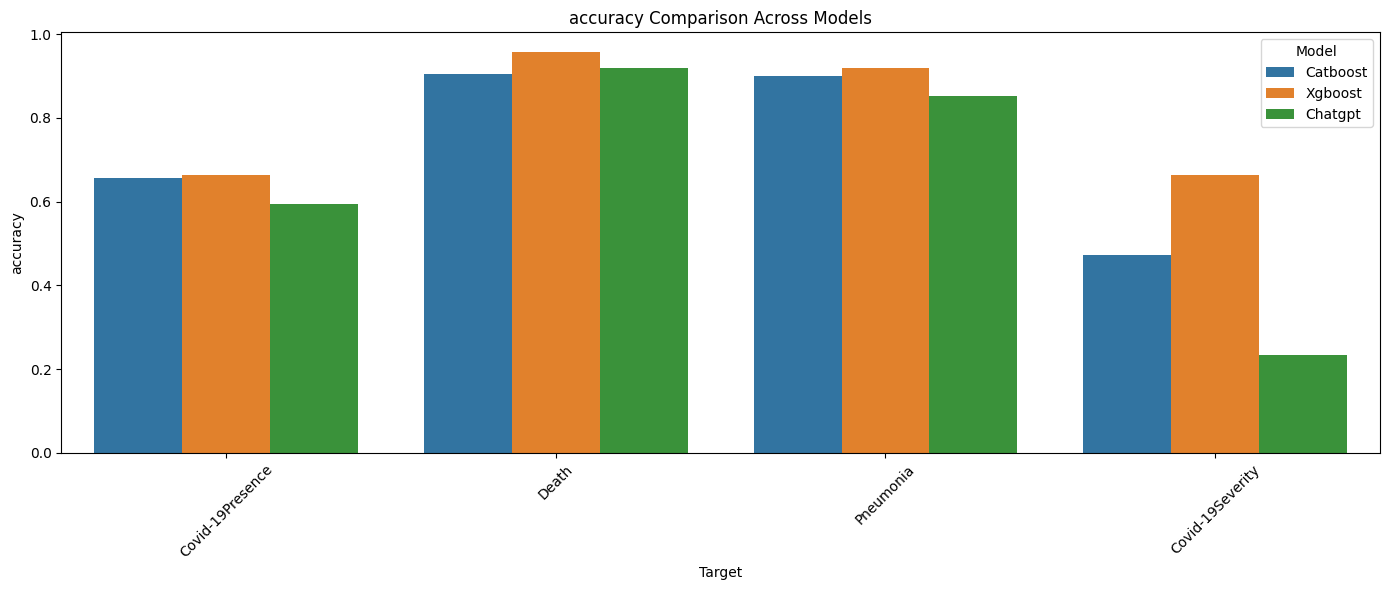

C:\Users\nehan\AppData\Local\Temp\ipykernel_25536\956012294.py:83: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_metric, x="target", y=metric, hue="model", ci=None)


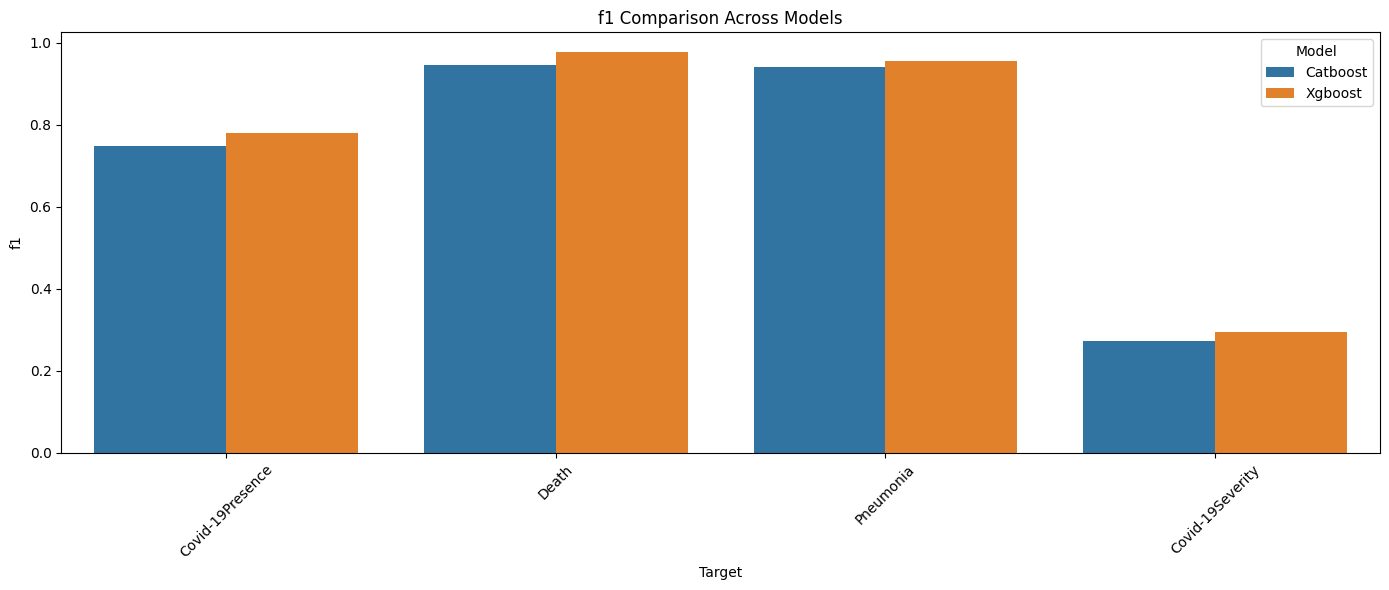

C:\Users\nehan\AppData\Local\Temp\ipykernel_25536\956012294.py:83: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_metric, x="target", y=metric, hue="model", ci=None)


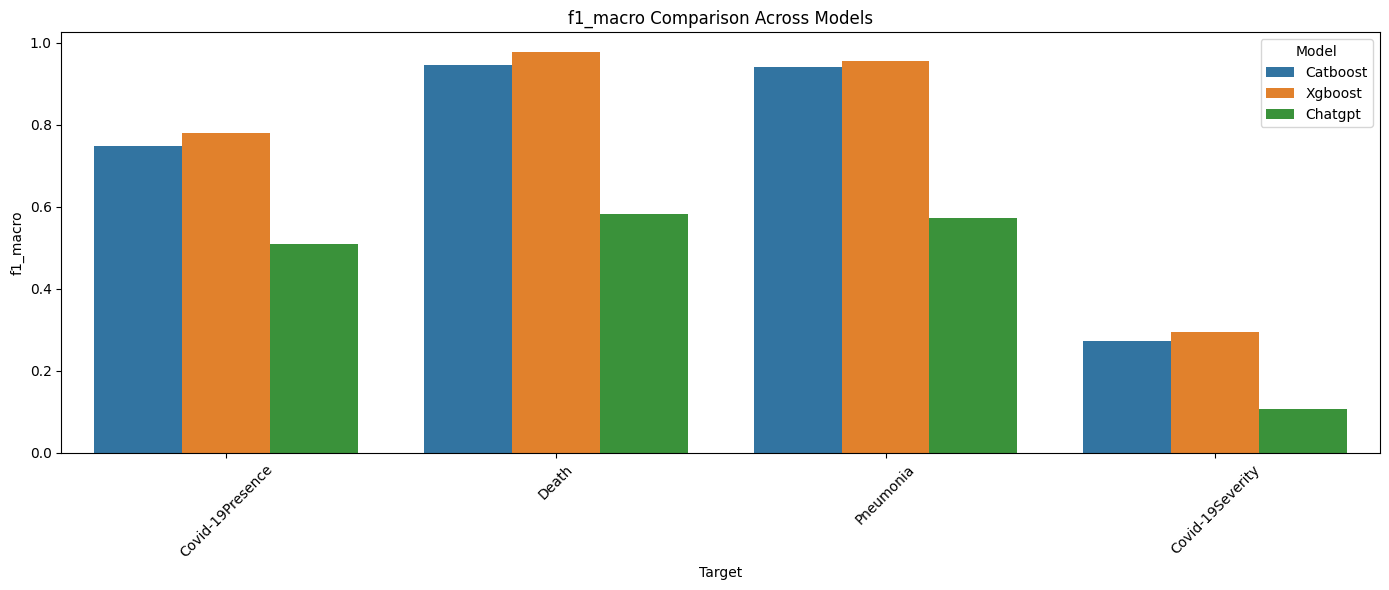

C:\Users\nehan\AppData\Local\Temp\ipykernel_25536\956012294.py:83: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_metric, x="target", y=metric, hue="model", ci=None)


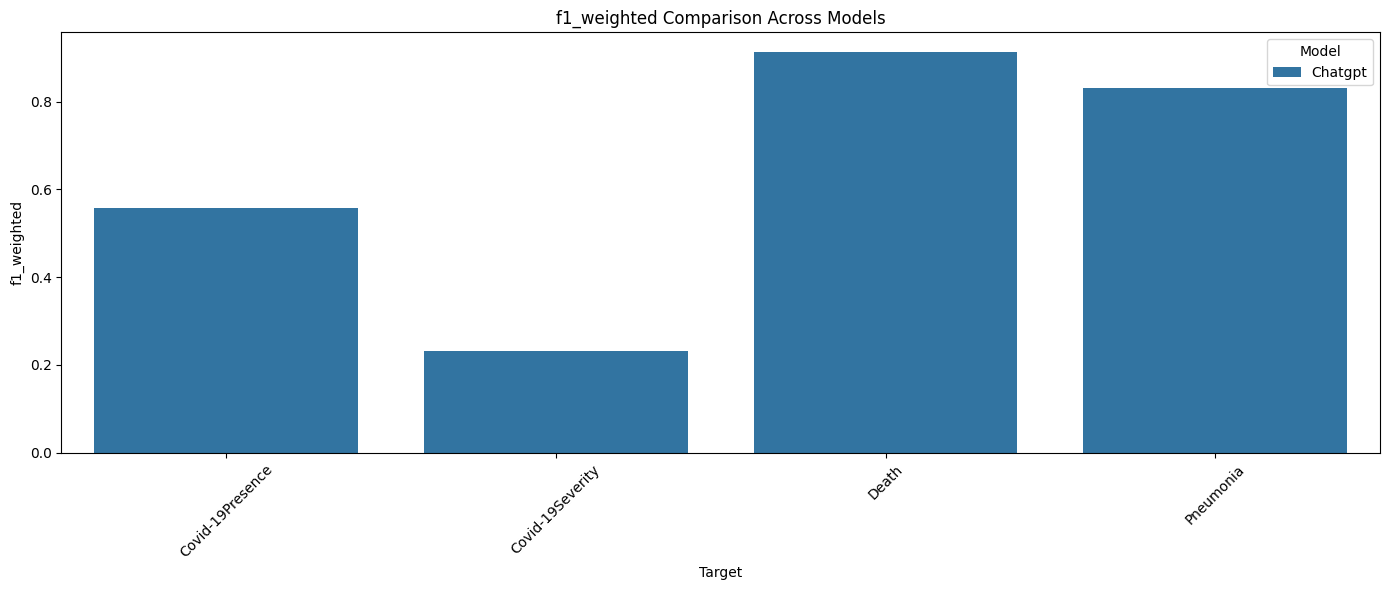

C:\Users\nehan\AppData\Local\Temp\ipykernel_25536\956012294.py:83: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_metric, x="target", y=metric, hue="model", ci=None)


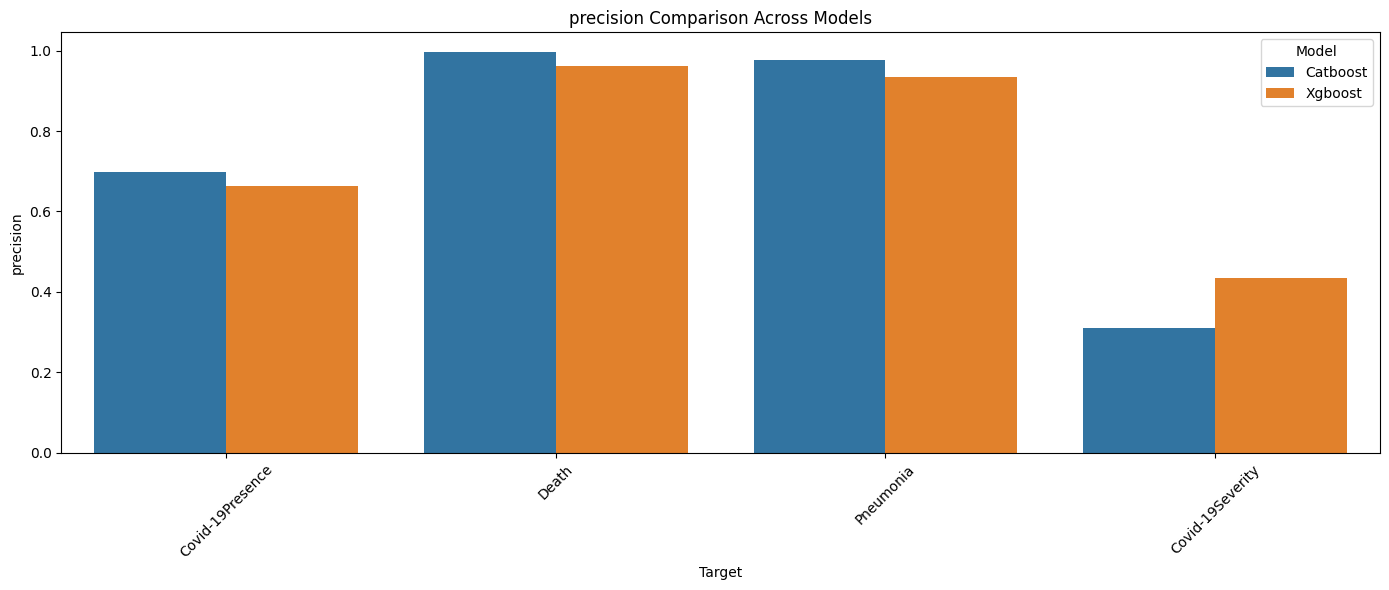

C:\Users\nehan\AppData\Local\Temp\ipykernel_25536\956012294.py:83: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_metric, x="target", y=metric, hue="model", ci=None)


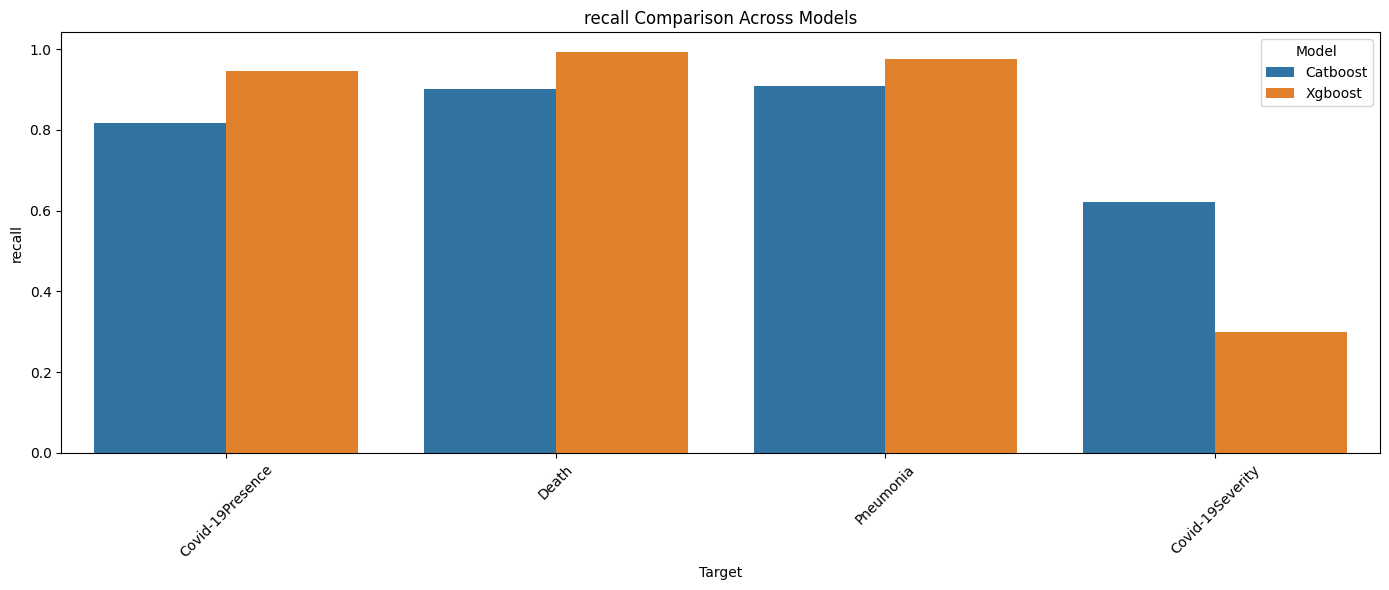

C:\Users\nehan\AppData\Local\Temp\ipykernel_25536\956012294.py:83: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_metric, x="target", y=metric, hue="model", ci=None)


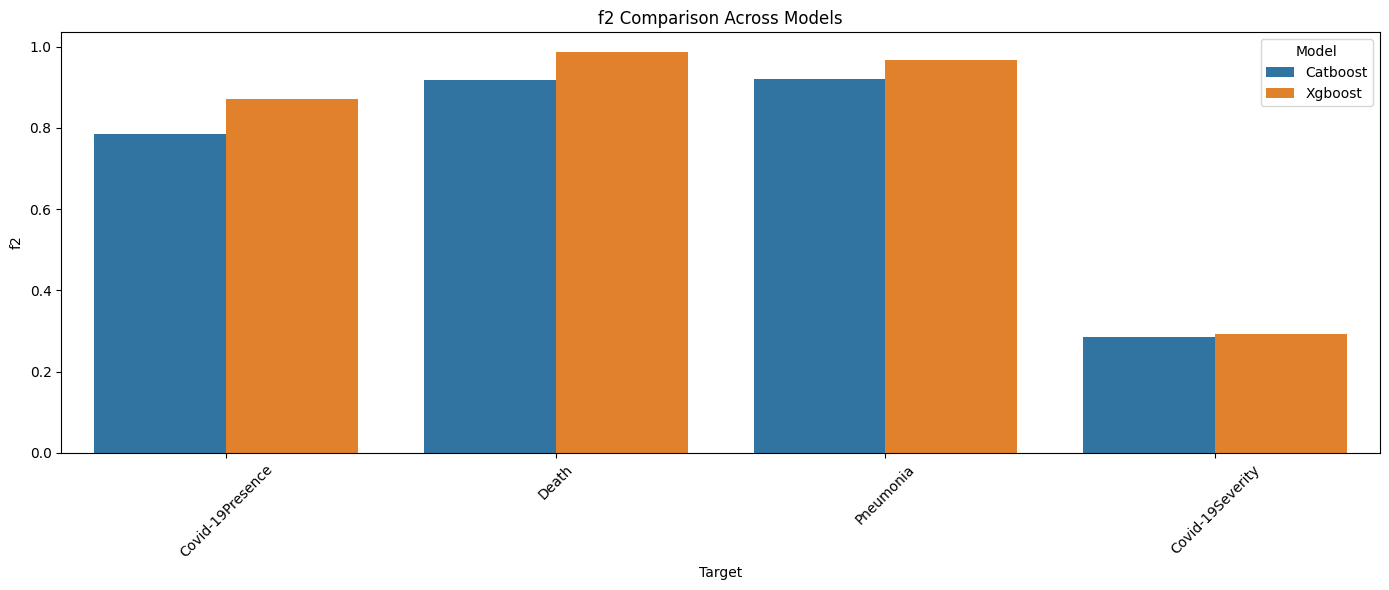

C:\Users\nehan\AppData\Local\Temp\ipykernel_25536\956012294.py:83: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_metric, x="target", y=metric, hue="model", ci=None)


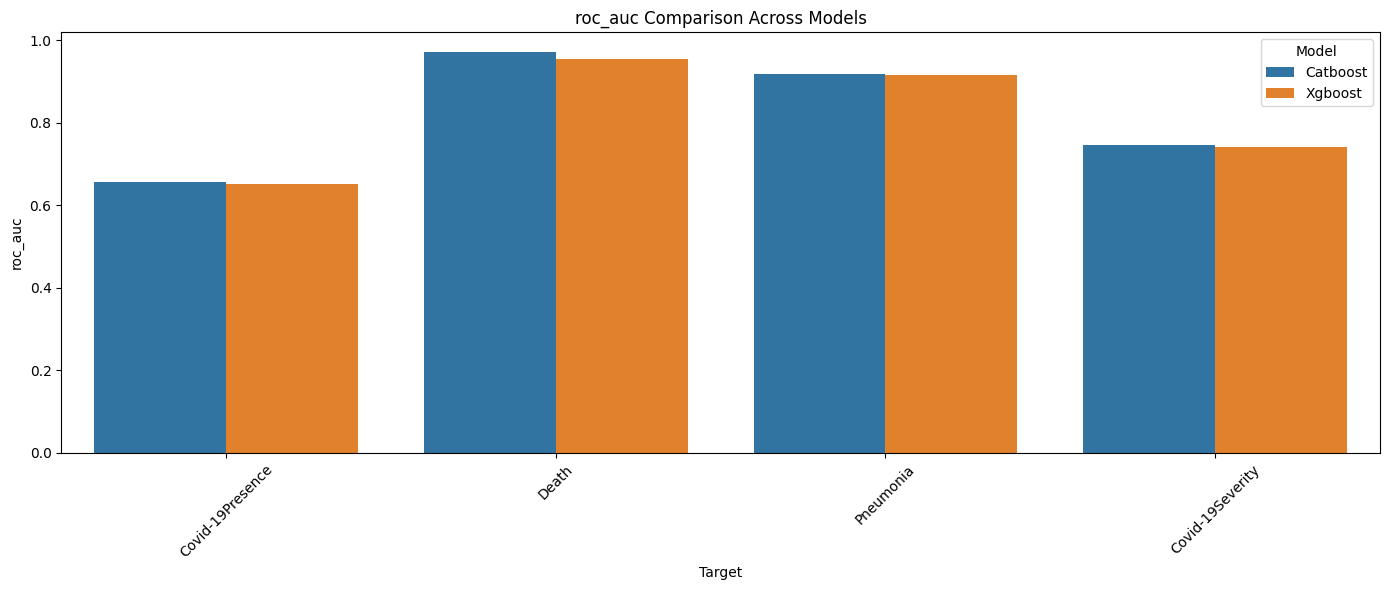

C:\Users\nehan\AppData\Local\Temp\ipykernel_25536\956012294.py:83: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_metric, x="target", y=metric, hue="model", ci=None)


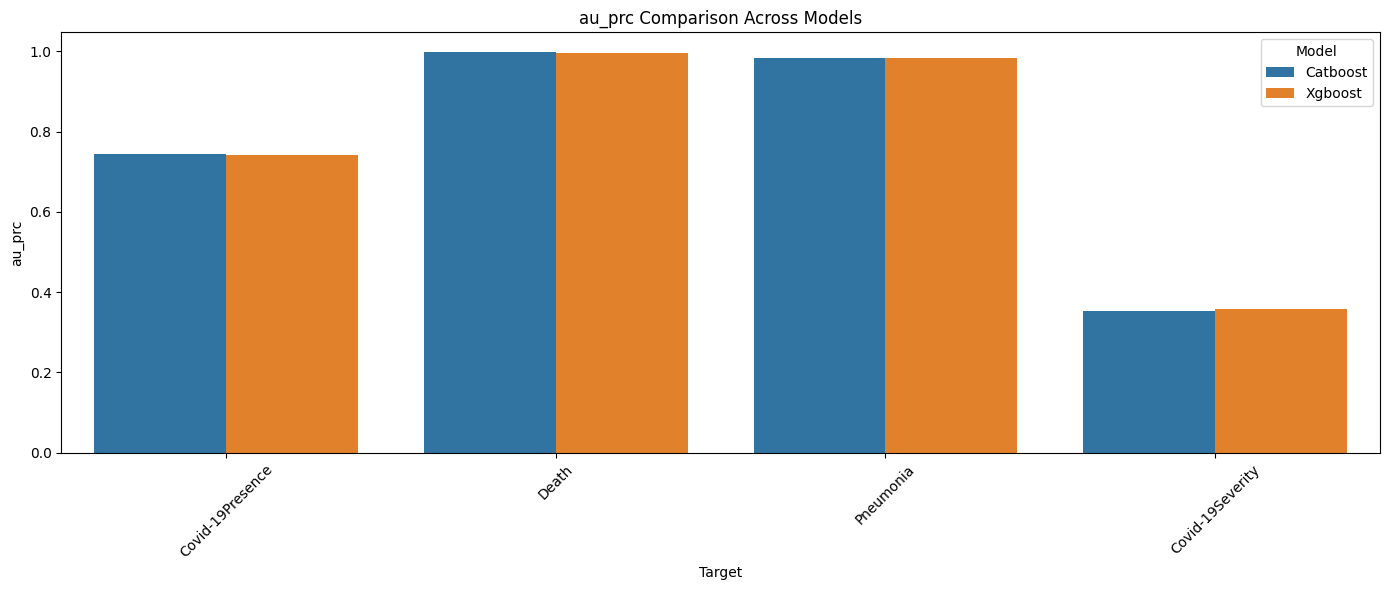

C:\Users\nehan\AppData\Local\Temp\ipykernel_25536\956012294.py:83: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_metric, x="target", y=metric, hue="model", ci=None)


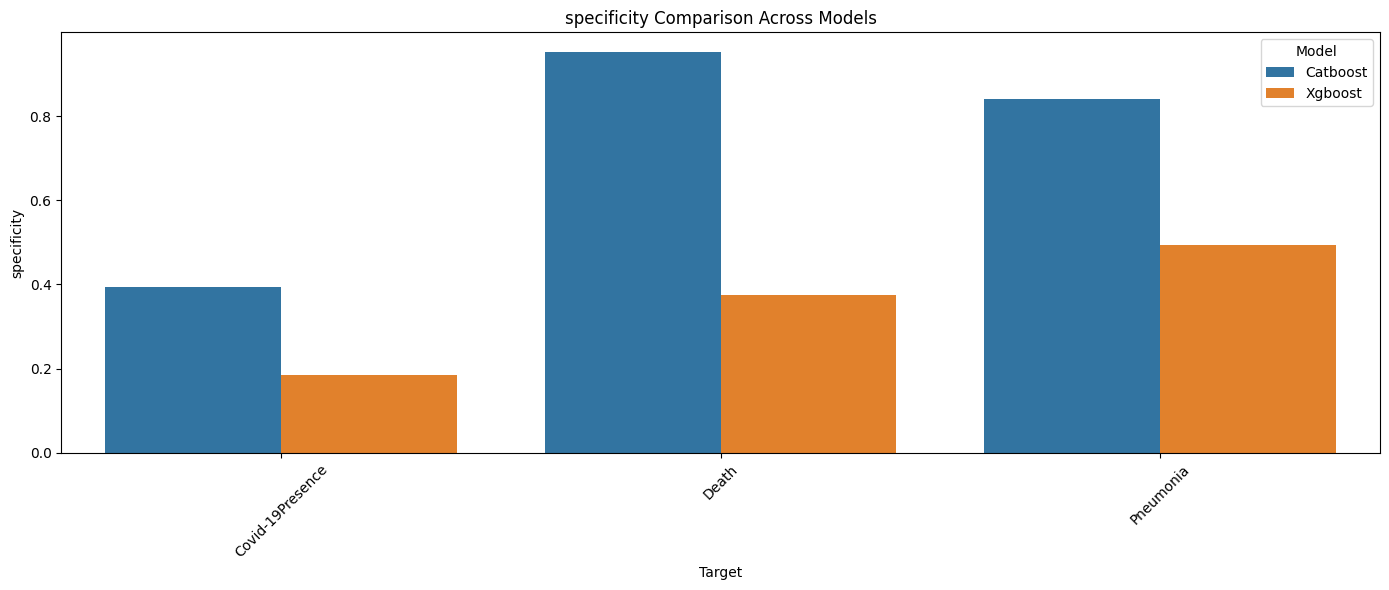

C:\Users\nehan\AppData\Local\Temp\ipykernel_25536\956012294.py:83: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_metric, x="target", y=metric, hue="model", ci=None)


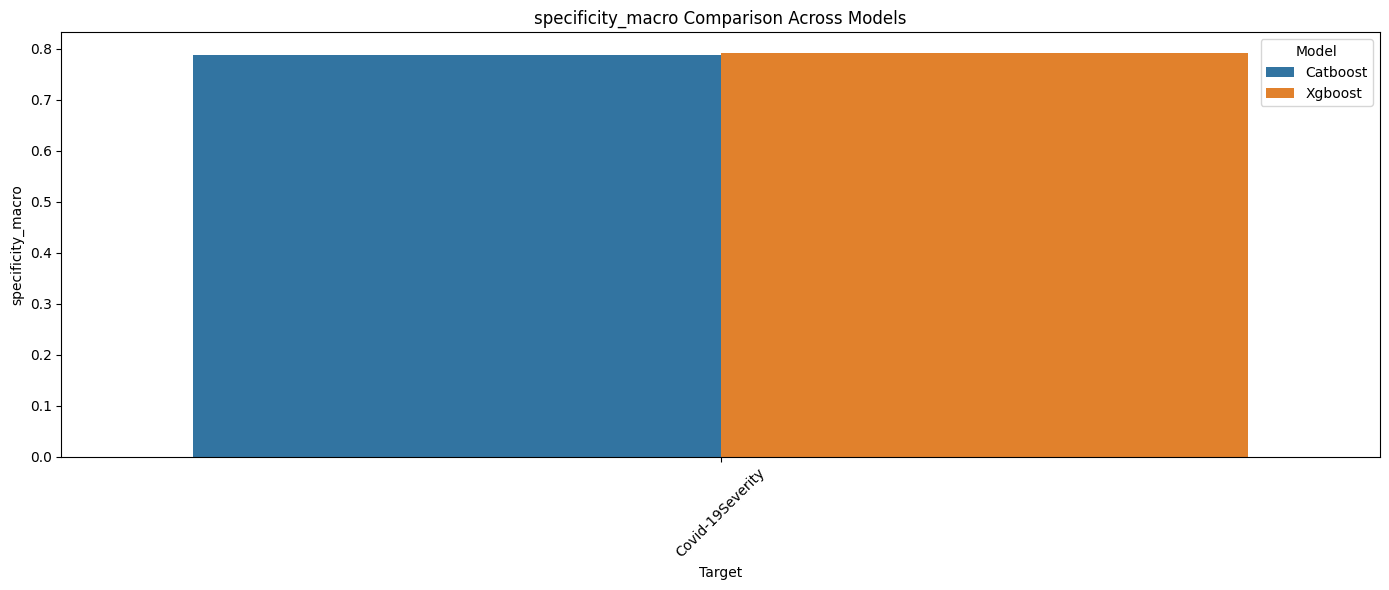

C:\Users\nehan\AppData\Local\Temp\ipykernel_25536\956012294.py:83: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_metric, x="target", y=metric, hue="model", ci=None)


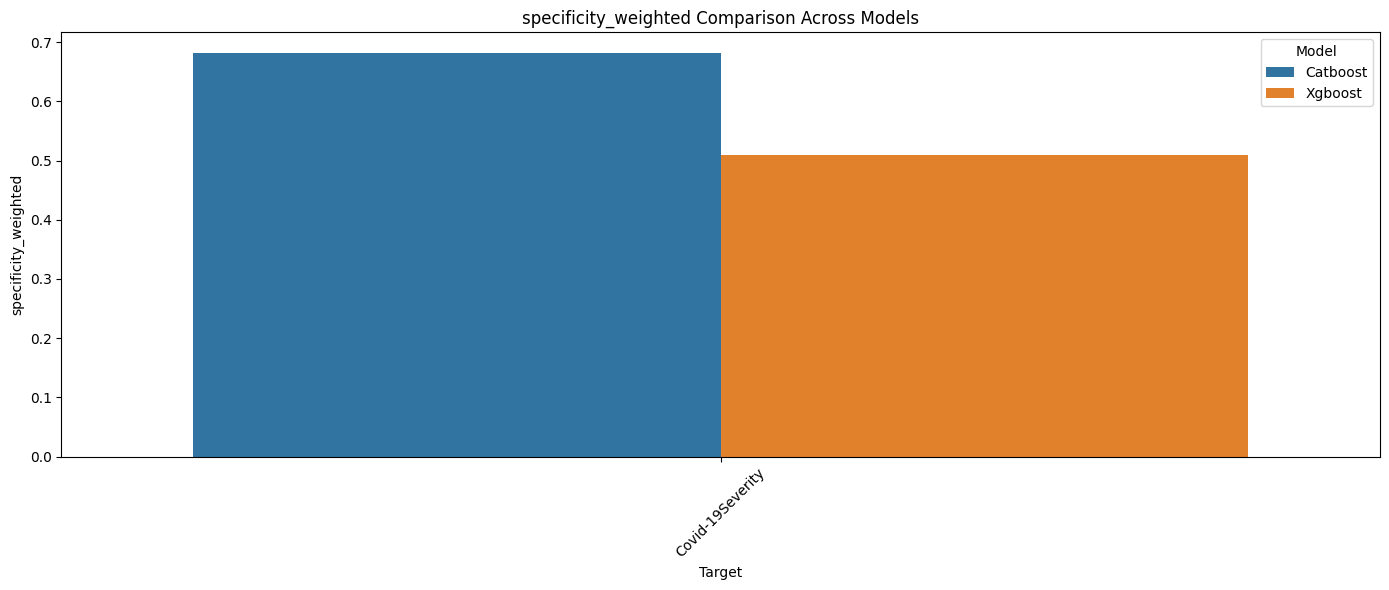

C:\Users\nehan\AppData\Local\Temp\ipykernel_25536\956012294.py:83: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_metric, x="target", y=metric, hue="model", ci=None)


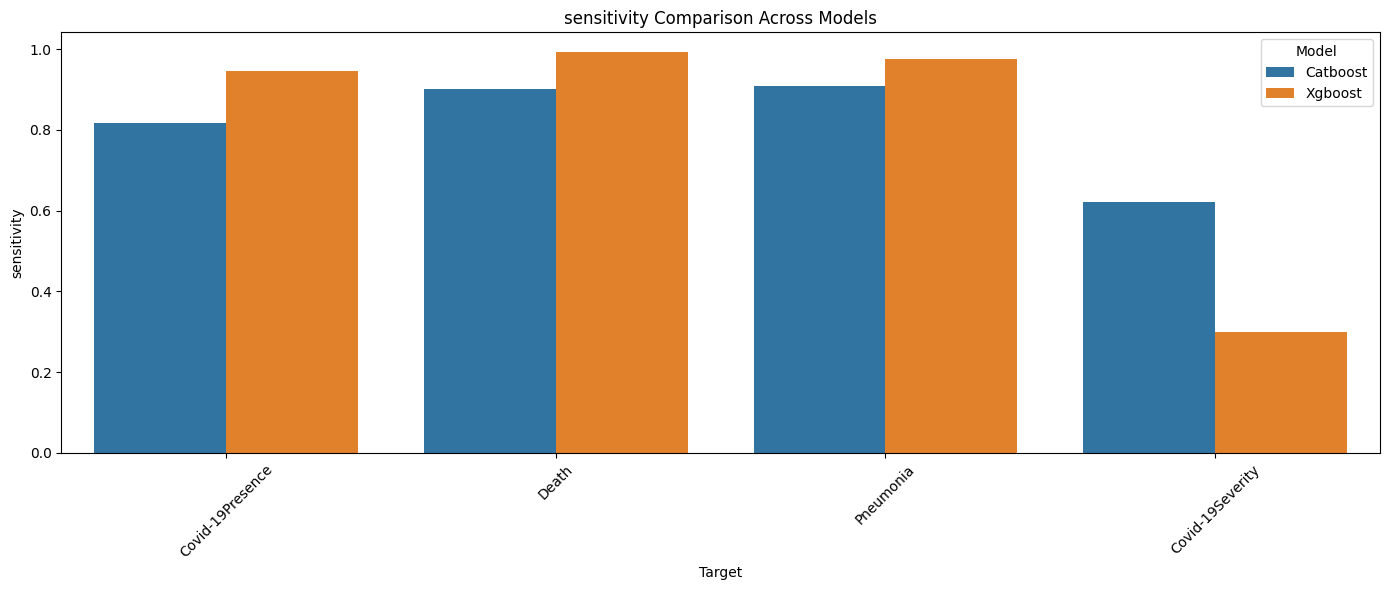

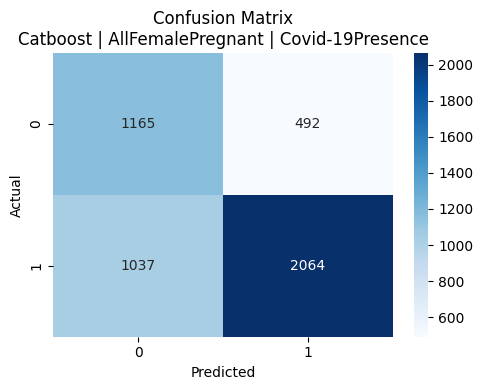

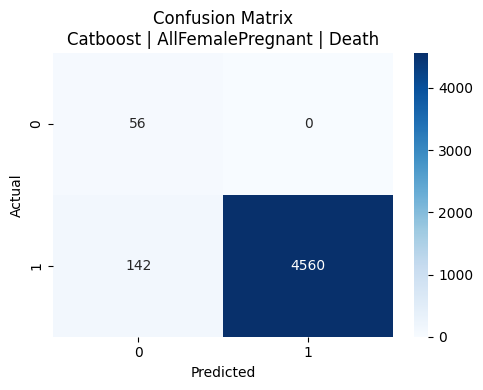

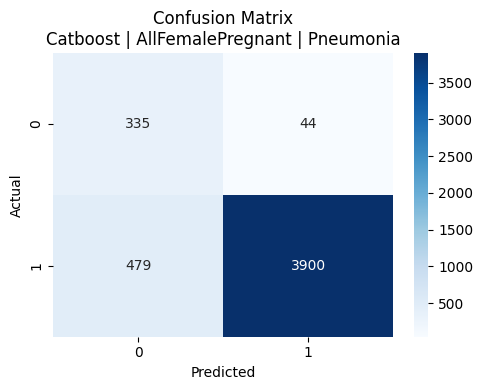

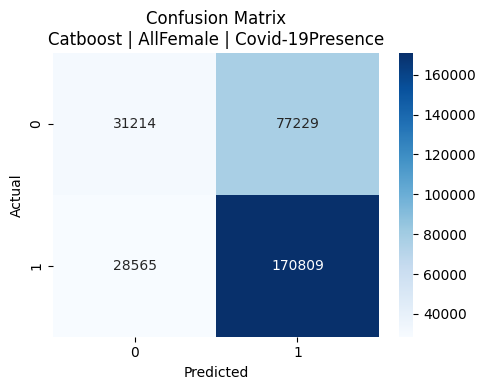

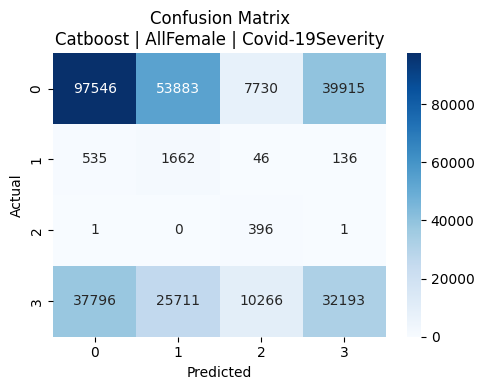

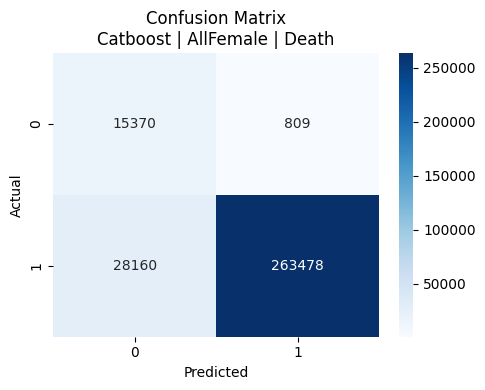

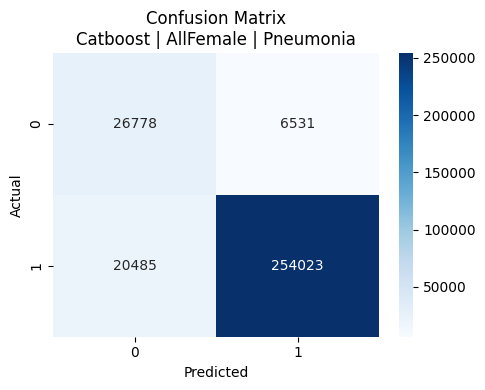

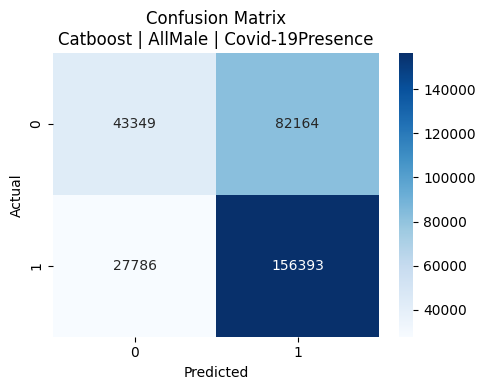

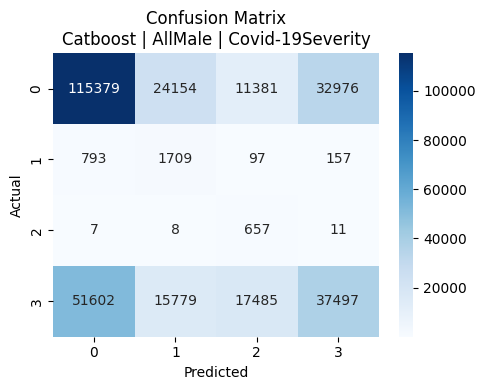

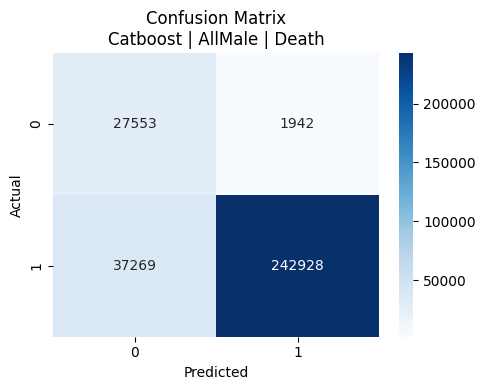

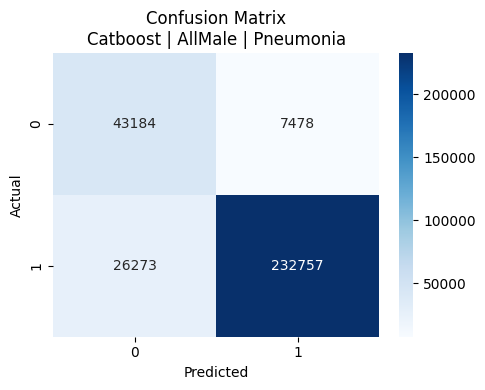

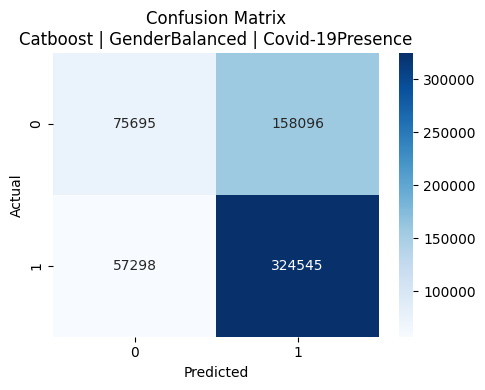

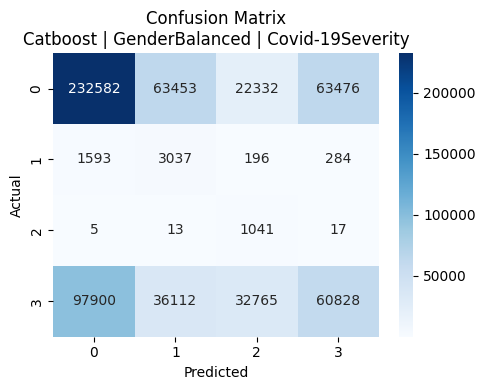

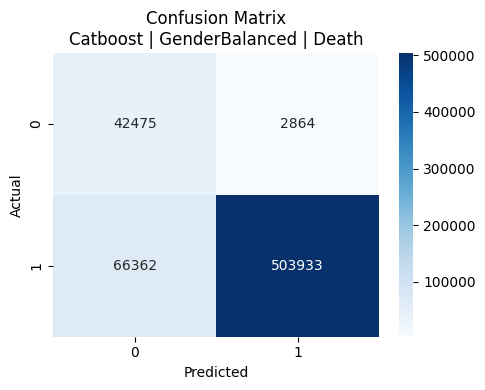

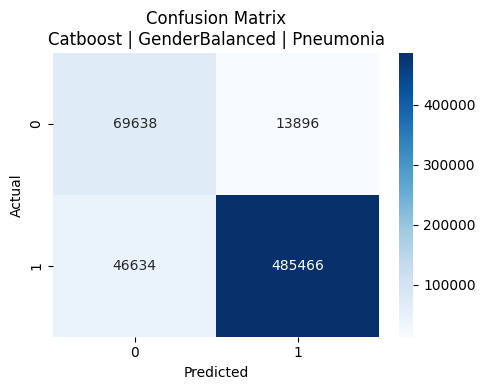

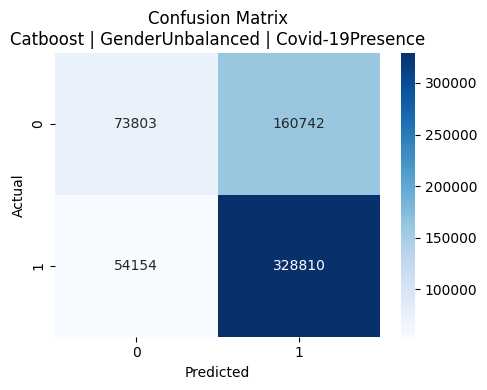

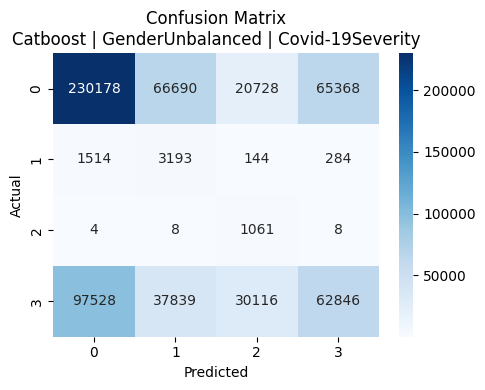

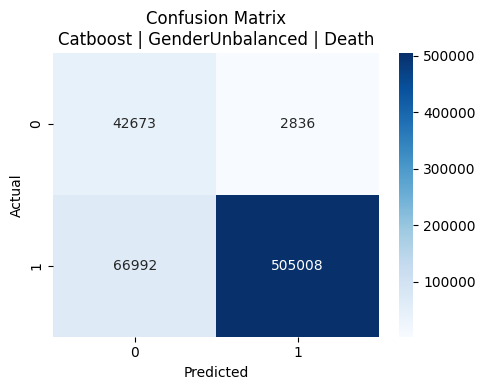

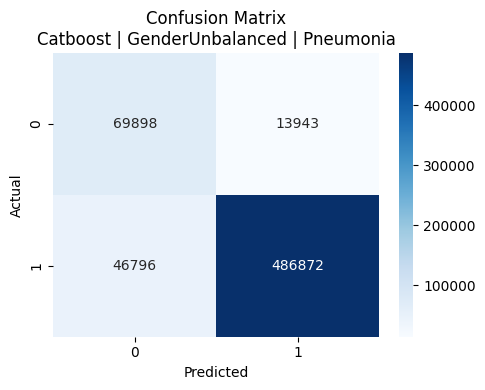

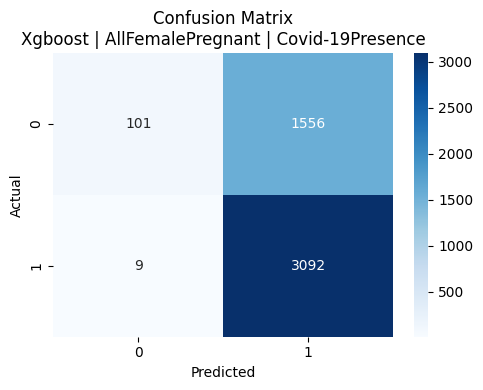

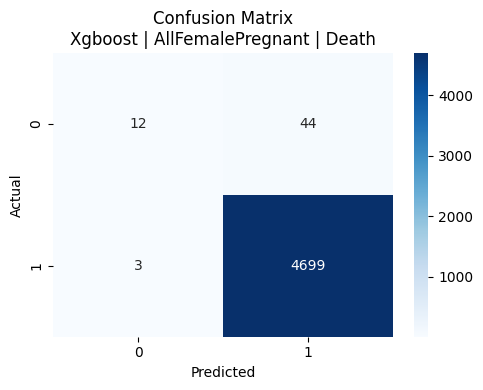

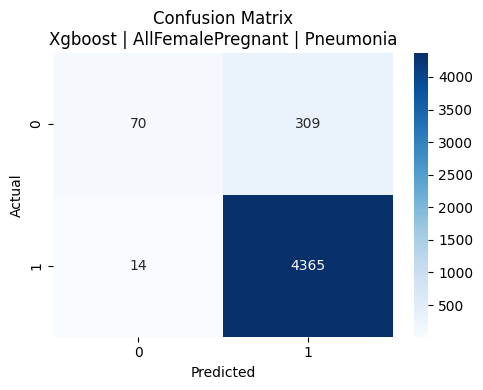

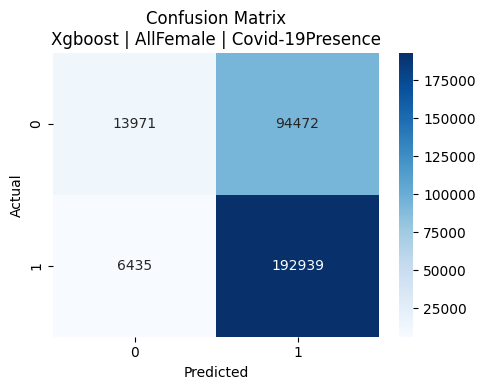

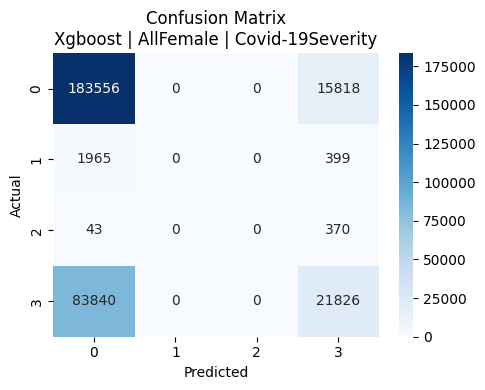

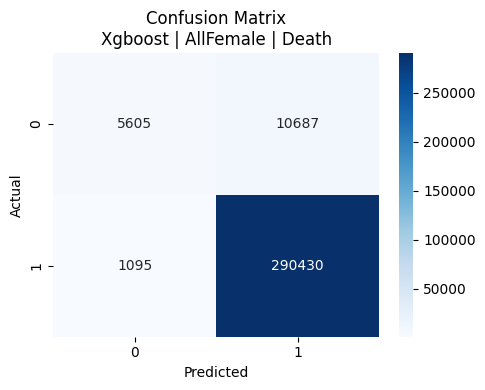

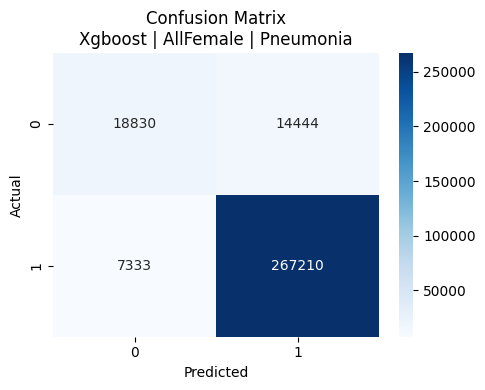

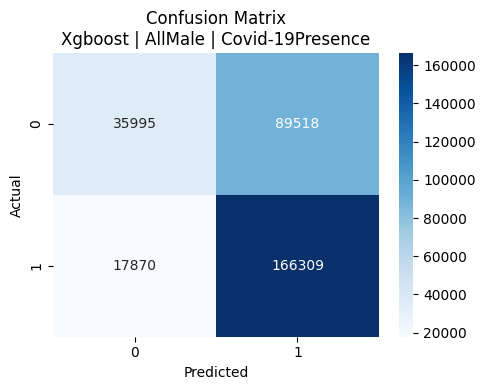

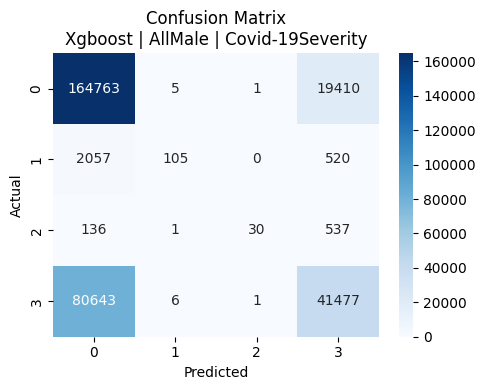

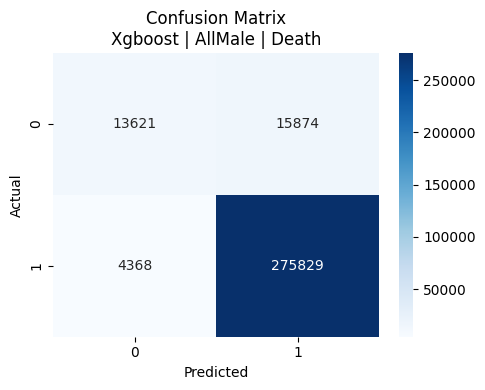

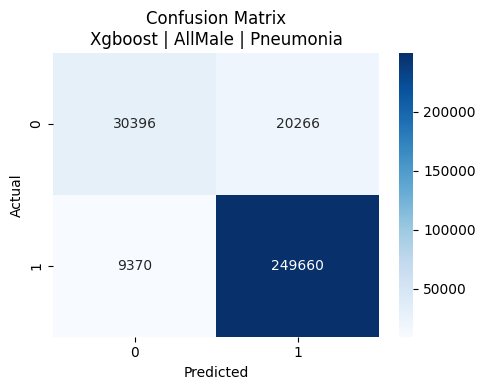

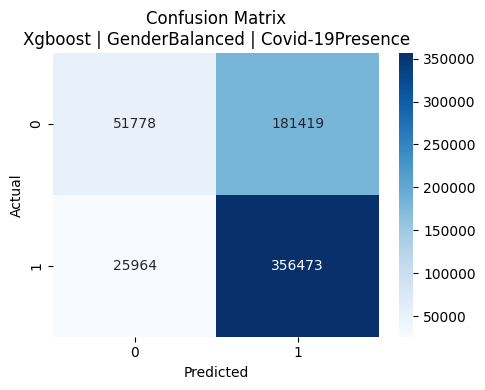

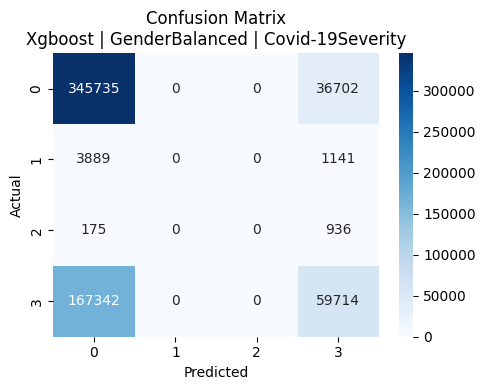

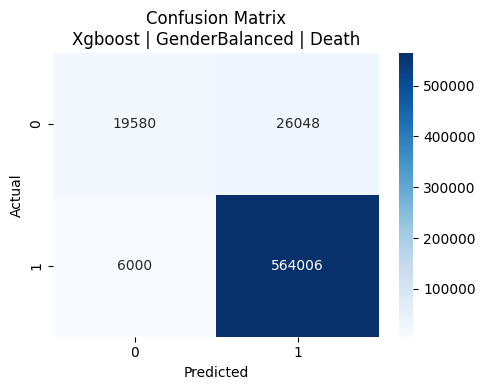

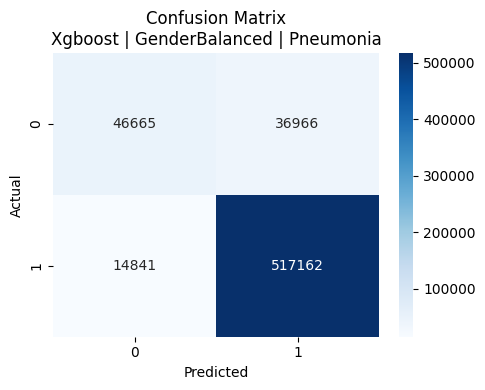

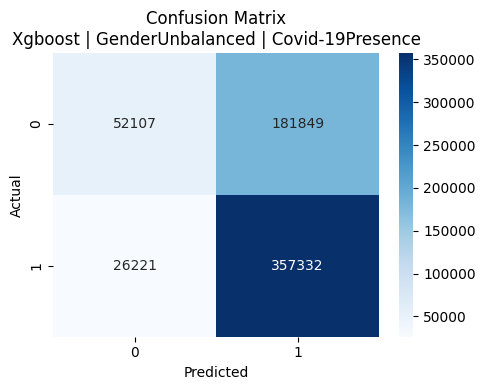

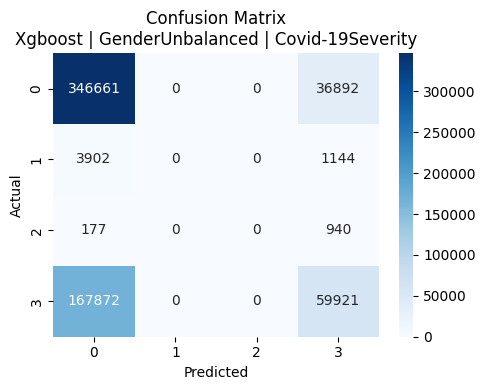

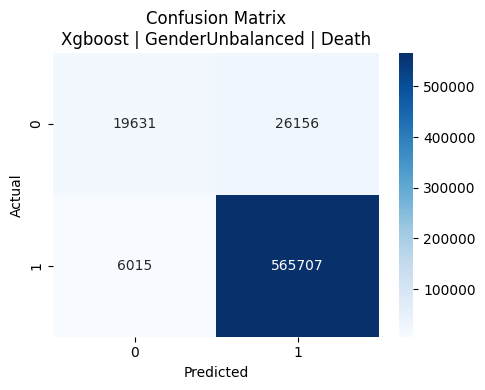

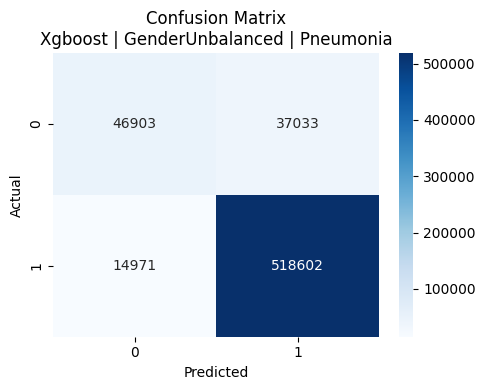

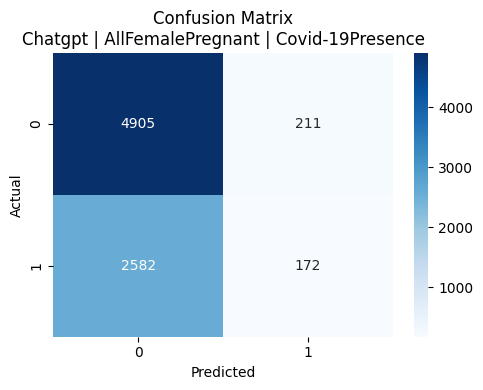

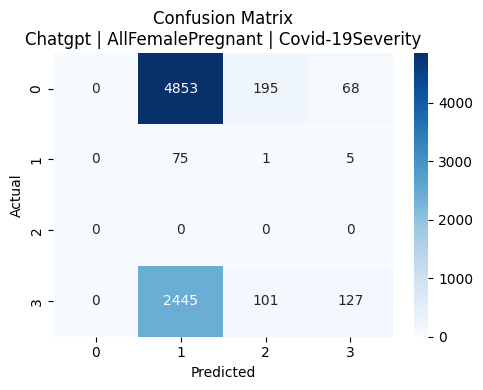

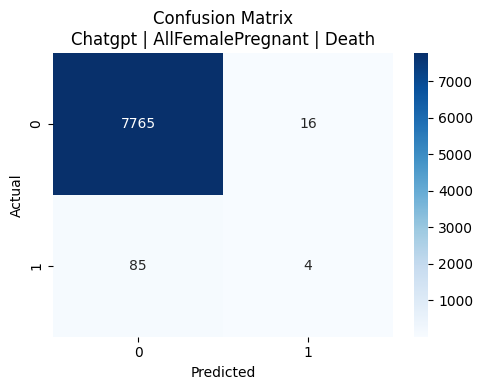

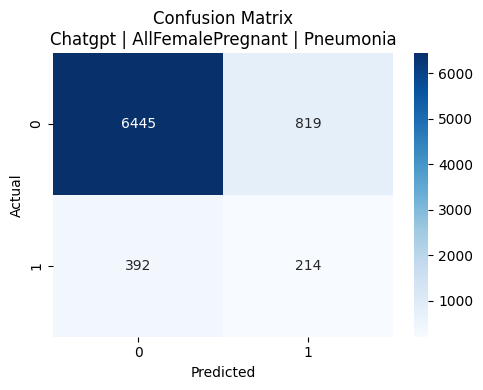

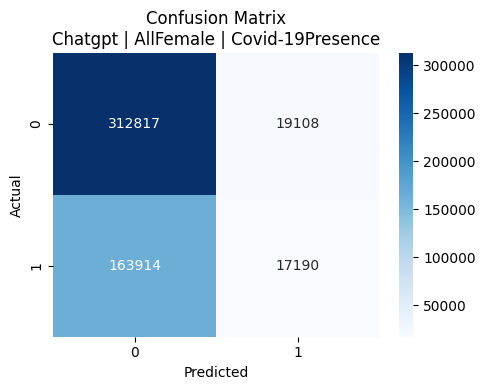

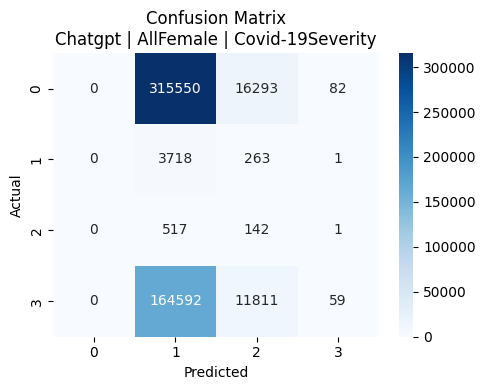

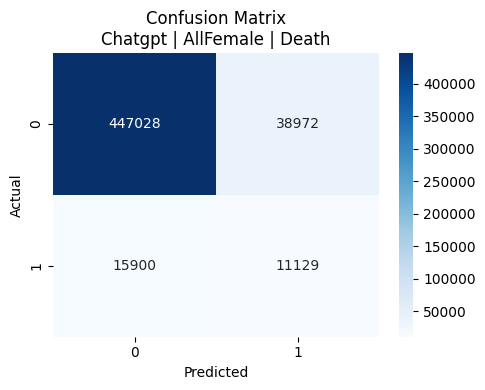

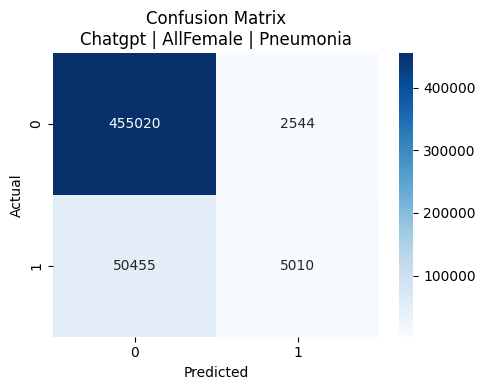

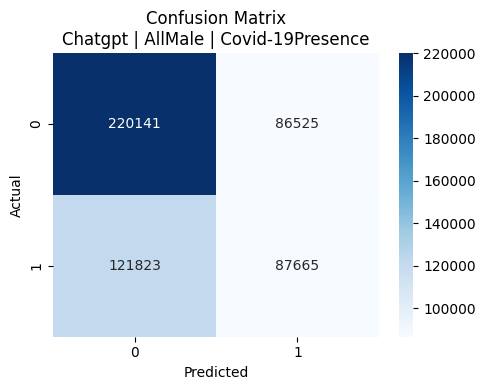

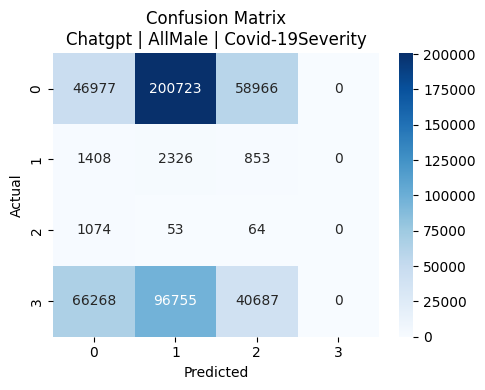

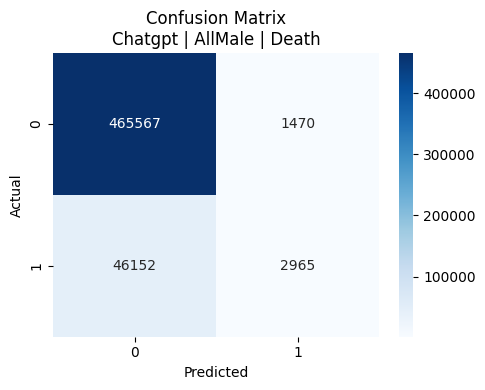

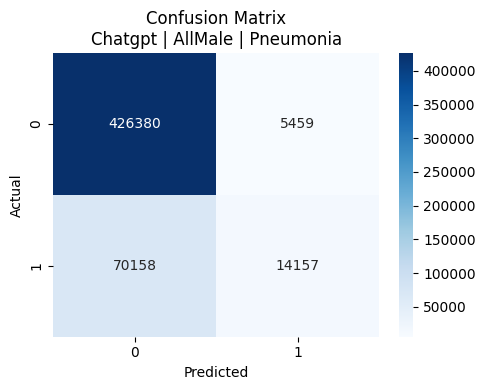

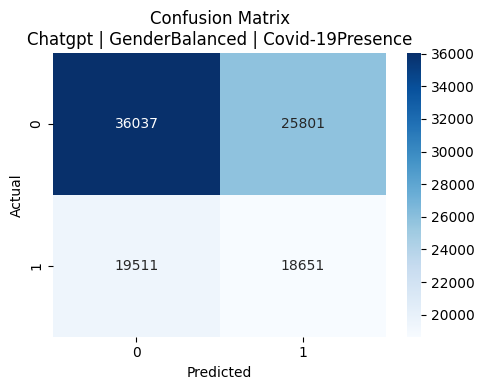

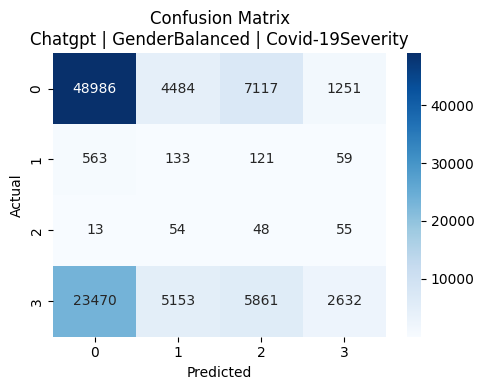

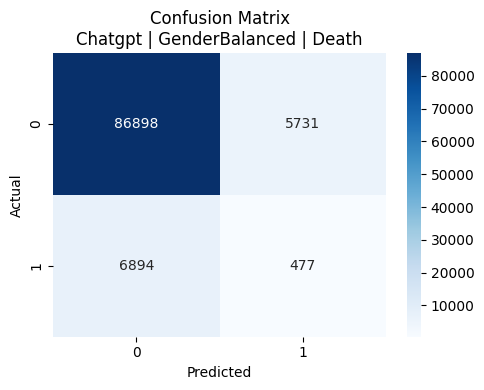

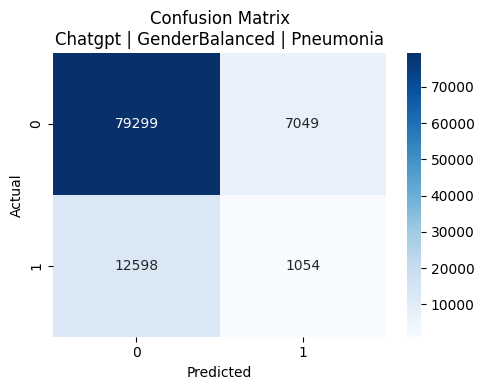

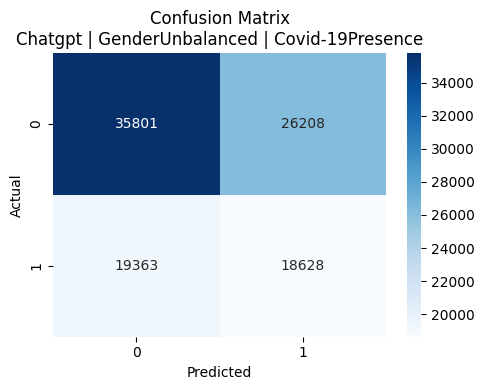

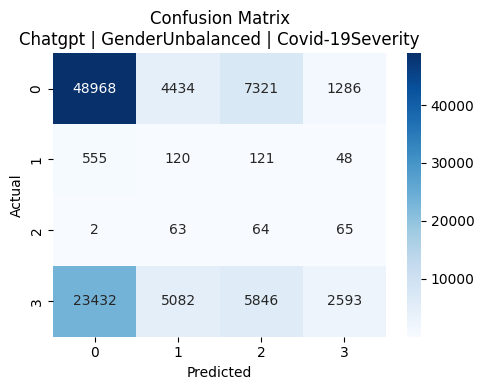

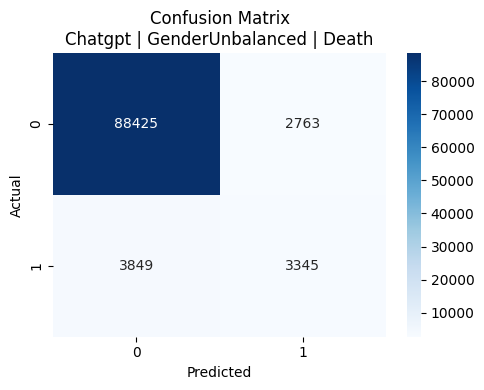

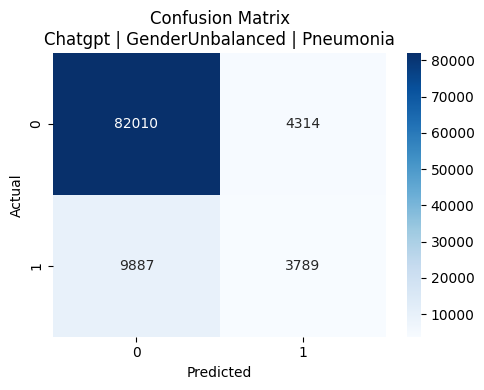

In [11]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob

# === 📁 Paths to metric folders
cml_dir = r"C:\Users\nehan\Documents\GT\CS 4641\ML_vs_LLM_COVID_GenderBias\Metric Output Files\CML"
llm_dir = r"C:\Users\nehan\Documents\GT\CS 4641\ML_vs_LLM_COVID_GenderBias\Metric Output Files\LLM"
all_dirs = [cml_dir, llm_dir]

# === 📥 Load and flatten metrics
all_metrics = []

for folder in all_dirs:
    json_files = glob(os.path.join(folder, "*.json"))
    print(f"🔍 Looking in: {folder} — Found {len(json_files)} files")

    for file in json_files:
        with open(file, 'r') as f:
            data = json.load(f)

        filename = os.path.basename(file).replace(".json", "")
        parts = filename.split("_")
        if len(parts) < 3:
            print(f"⚠️ Skipping malformed file: {filename}")
            continue

        model_name = parts[0]  # e.g. Xgboost, Catboost, Chatgpt
        gender = parts[1]
        target = "_".join(parts[2:])

        flat = {
            "model": model_name,
            "gender": gender,
            "target": target,
            "accuracy": data.get("accuracy"),
            "f1_macro": data.get("f1_macro") or data.get("f1"),
            "f1_weighted": data.get("f1_weighted"),
            "precision": data.get("precision"),
            "recall": data.get("recall"),
            "f1": data.get("f1"),
            "f2": data.get("f2"),
            "roc_auc": data.get("roc_auc"),
            "au_prc": data.get("au_prc"),
            "specificity": data.get("specificity"),
            "specificity_macro": data.get("specificity_macro"),
            "specificity_weighted": data.get("specificity_weighted"),
            "sensitivity": data.get("sensitivity"),
            "tp": data.get("tp"),
            "tn": data.get("tn"),
            "fp": data.get("fp"),
            "fn": data.get("fn"),
            "confusion_matrix": data.get("confusion_matrix")
        }

        all_metrics.append(flat)
        print(f"✅ Loaded: {model_name} | {gender} | {target}")

# === 🧾 Create DataFrame
df = pd.DataFrame(all_metrics)

# === 📊 Ensure required columns
if df.empty or "model" not in df.columns or "target" not in df.columns:
    raise ValueError("❌ DataFrame is missing critical columns ('model', 'target'). Check file parsing.")

# === 📈 Plot comparison by metric
metrics_to_plot = [
    "accuracy", "f1", "f1_macro", "f1_weighted", "precision", "recall",
    "f2", "roc_auc", "au_prc", "specificity", "specificity_macro", "specificity_weighted", "sensitivity"
]

df_filtered = df.dropna(subset=["target", "model"])

for metric in metrics_to_plot:
    df_metric = df_filtered.dropna(subset=[metric])
    if df_metric.empty:
        print(f"⚠️ Skipping {metric} — no data available.")
        continue

    plt.figure(figsize=(14, 6))
    sns.barplot(data=df_metric, x="target", y=metric, hue="model", ci=None)
    plt.title(f"{metric} Comparison Across Models")
    plt.xticks(rotation=45)
    plt.ylabel(metric)
    plt.xlabel("Target")
    plt.legend(title="Model")
    plt.tight_layout()
    plt.show()

# === 🔥 Plot confusion matrices
for _, row in df_filtered.iterrows():
    cm = row.get("confusion_matrix")
    if isinstance(cm, list) and cm:
        plt.figure(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
        plt.title(f"Confusion Matrix\n{row['model']} | {row['gender']} | {row['target']}")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.tight_layout()
        plt.show()
